# NB03d — Source Product Audit and Plan-Based Prune

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.



| Field | Value |
|-------|-------|
| **Notebook** | `03d_bda_Product_Audit_Prune1_v12.ipynb` |
| **Version** | v12 |
| **Pipeline position** | QA/Maintenance. After NB03a/b/c (extraction), before NB03e (derived products). |
| **Last validated** | 2026-04-XX |

## Narrative

Three-pass audit of source products (COH, CARD, MS TIFs) against the unified
scene plan from NB02a. Flags and optionally quarantines products that are
contaminated, off-plan, or corrupt.

**Pass 1 — ORBIT**: Detect multi-orbit contamination via filename orbit tag.
TIFs from the wrong orbit cause zigzag nodata patterns in temporal plots (the
contamination bug discovered in prior sessions).

**Pass 2 — DATE**: Flag TIFs whose dates are NOT in `nb02a_scene_plan.json`.
These are leftovers from previous processing runs with different scene selections.
COH pairs are checked against both dates in the pair.

**Pass 3 — CORRUPT**: Detect truncated, unreadable, or nodata-flooded TIFs by
reading a center patch and checking against `NODATA_SENTINEL=-100dB`.

Flagged files are quarantined (moved to `_quarantine/`) rather than deleted,
preserving the option to recover. All audit results are synced to `bda.sqlite`.

The notebook also includes a rename cell that migrates legacy filenames to the
double-underscore convention and adds orbit tags from zip lookup.

## Scientific Rationale
Data quality assurance is essential before feature extraction. Multi-orbit
contamination directly corrupts backscatter statistics (Dietrich features) by
mixing different viewing geometries. Nodata-flooded TIFs silently inject NaN
into downstream zonal statistics, which NB09e showed has larger impact on
classification than classifier choice. This notebook ensures only plan-consistent,
orbit-correct, non-corrupt products enter NB03e and NB05.

## Inputs

| Data | Source | Format |
|------|--------|--------|
| `nb02a_scene_plan.json` | NB02a | JSON (expected dates + orbits per city) |
| COH TIFs | `SAR_COH_DIR/{city}/` (NB03c) | GeoTIFF |
| CARD TIFs | `SAR_CARD_DIR/{city}/` (NB03b) | GeoTIFF |
| MS TIFs | `MS_DIR/{city}/` (NB03a) | GeoTIFF |
| `AOI.geojson` per city | NB01b | GeoJSON (for extent validation) |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| Quarantined TIFs | `SATELLITE_DIR/_quarantine/` | Recovery if needed |
| Renamed TIFs (__ convention + orbit) | In-place in source dirs | NB03e, NB05 |
| `bda.sqlite` (audit_results table) | `CATALOG_DB` | Audit trail |
| Audit report (in-notebook) | — | Operator review |

## Prerequisites
- NB03a/b/c must have run (source TIFs exist)
- NB02a must have run (plan exists)
- NB01b must have run (AOI.geojson for extent check)

## Key Methodological Choices

| Choice | Justification | Reference |
|--------|---------------|-----------|
| Quarantine, not delete | Reversible — avoids re-downloading/reprocessing | Safety |
| DRY_RUN=True default | Prevent accidental quarantine | Safety |
| Three-pass (orbit, date, corrupt) | Each pass catches different failure mode | Completeness |
| NODATA_SENTINEL=-100dB | CARD constant-value TIFs from contamination bug | Empirical |
| Center patch check (10x10) | Fast corrupt detection without full raster read | Efficiency |
| Orbit tag from filename | No need to reopen TIF or check metadata | Performance |
| Source-only scan (skip derived) | Derived products will be regenerated by NB03e | Architecture |

## Known Limitations
- Legacy TIFs without orbit tag cannot be checked in P1 (flagged separately)
- P3 corrupt check only reads center — edge corruption may be missed
- Rename cell modifies filenames in-place — affects NB03c tracker references

## Python Modules

| Module | Cell | What |
|--------|------|------|
| `data_verification.py` | Cell 4B | Directory structure verification |
| `product_pre_audit.py` | Cell PRE-AUDIT | COH product validator |

## Cell Structure

| Cell | ID | What | Status |
|------|----|------|--------|
| 0 | — | Documentation (this cell) | — |
| 1 | CONFIG | Config (DRY_RUN flags, thresholds) | Config |
| 2 | SETUP | Load global_setup | Config |
| 3 | Cell 1 | Load plan + tier selection | **Core** |
| 4-5 | Cell 4B | Data verification | QA |
| 6-7 | PRE-AUDIT | COH product validator | QA |
| 8 | SCAN | Count source products per city (COH/CARD/MS) | **Core** |
| 9 | RENAME | Migrate to __ convention + add orbit tag | **Core** |
| 10 | PLAN-LOAD | Read unified scene plan for prune passes | **Core** |
| 11 | P1-ORBIT | Detect wrong-orbit TIFs from filename | **Core** |
| 12 | P2-DATE | Flag TIFs with dates not in plan | **Core** |
| 13 | P3-CORRUPT | Detect truncated / nodata-flood TIFs | **Core** |
| 14 | PRUNE | Quarantine all flagged files (P1+P2+P3) | Optional |
| 15 | SQLITE | Sync audit + prune to bda.sqlite | **Core** |
| 16 | SUMMARY | Completion report with counts | QA |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.3 Preprocessing — Quality Control | P1, P2, P3 | Three-pass audit methodology |
| 3.3 Preprocessing — Data Management | RENAME, PRUNE | Naming convention, quarantine strategy |
| 4.x Results — Data Quality | SUMMARY | Audit statistics |

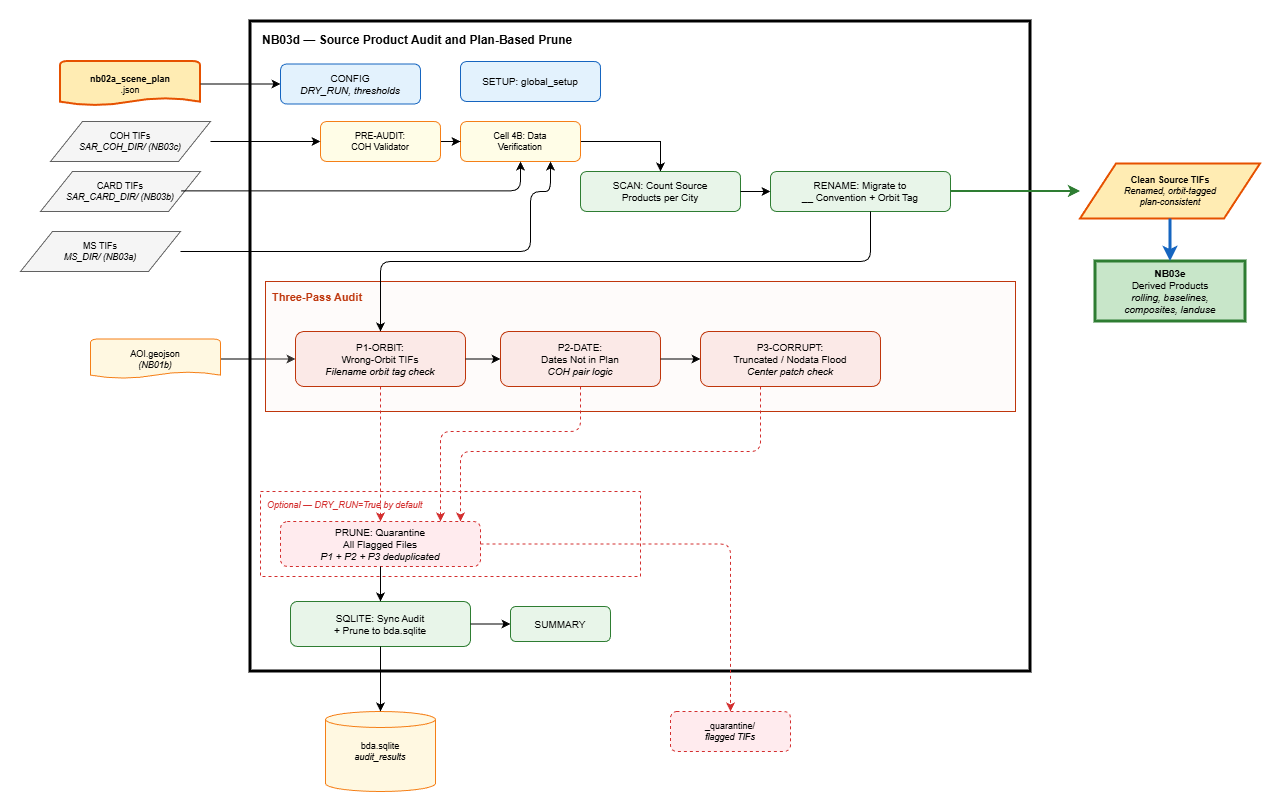

In [1]:
# @title CELL CONFIG
NOTEBOOK_ID = 'NB03d'
DRY_RUN_RENAME = False        # True = report only, False = execute renames
DRY_RUN_PRUNE = False          # True = report only, False = delete
VERBOSE = True

# orbit check: sample N TIFs per city to detect multi-extent
ORBIT_SAMPLE_SIZE = 100

# corrupt check: flag TIFs where center patch mean == NODATA_SENTINEL
NODATA_SENTINEL = -100.0
CORRUPT_PATCH_SIZE = 10       # read NxN center patch (P3)

# P4 garbage check: full-raster sentinel fraction (not just center patch)
# Scenes with sentinel fraction >= GARBAGE_FRAC_THRESHOLD are unusable.
# Edge-of-swath scenes (<80% sentinel) are kept, NB03e v43 treats their
# per-pixel NaN via the valid mask pattern.
ENABLE_P4_GARBAGE = True
GARBAGE_FRAC_THRESHOLD = 0.85
GARBAGE_DOWNSAMPLE = 500      # NxN downsampled read for fast scan (~36x speedup)



In [2]:
# @title CELL SETUP: LOAD GLOBAL ENVIRONMENT
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\PROJECTS\masterthesis\gdrive\masterthesis\notebooks\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())

/home/alpineobotics/miniconda3/envs/bda/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


BDA GLOBAL SETUP
Started: 2026-04-20 13:03:53
Python: 3.12.12

[1/7] Directory Structure
----------------------------------------------------------------------
  GDrive (G:):       /content/drive_f/masterthesis OK
  GDrive (F:):       /content/drive_f/masterthesis OK
  Local data (G:):   /content/masterthesis_local/data OK
  Data stack (F:):   /mnt/f/PROJECTS/masterthesis/data_stack OK

  TIER_SELECTION: [0, 1, 2]
  CITY_SELECTION: None (tier filter)
  REQUIRE_UNOSAT: False
  CITIES_TO_PROCESS: 21 cities

[2/7] Credentials
----------------------------------------------------------------------
  Copernicus: inf***
  OpenTopography: OK
  Earthdata: marcoheinzen

[3/7] Python Packages
----------------------------------------------------------------------


<string>:545: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.



  Already installed: 23
  Newly installed:   0
  Failed:            0

[4/7] Global Imports & Configuration
----------------------------------------------------------------------
  All imports loaded

[5/7] Processing Config & SNAP
----------------------------------------------------------------------
  GPT: Usage:
  Temporal baseline: 10-24 days
  Wavelength: 0.0555

[6/7] GPU Status
----------------------------------------------------------------------
  CUDA available: NVIDIA GeForce RTX 2070 SUPER
    CUDA version: 12.8

[7/7] Disk Space
----------------------------------------------------------------------
  GDrive (G:)     912.7/7452.0 GB (6539.3 GB free)
  GDrive (F:)     1642.6/3726.0 GB (2083.4 GB free)
  Local data      11515.0/14901.9 GB (3386.9 GB free)
  Data stack      1642.6/3726.0 GB (2083.4 GB free)
  WSL ext4        89.4/1006.9 GB (866.2 GB free)

GLOBAL SETUP COMPLETE
  Torch device: cuda
  Cities: 21, CITY=Avdiivka
  Functions: load_aoi(), load_aoi_gdf(), load_aoi_

In [3]:
# =============================================================================
# CELL 1: LOAD PLAN + TIER SELECTION (paste after global_setup cell)
# =============================================================================
import json
import re
from pathlib import Path
from datetime import datetime

PLAN_FILE = OUTPUTS_DIR / 'nb02a_scene_plan.json'
if not PLAN_FILE.exists():
    raise FileNotFoundError(f"Scene plan not found: {PLAN_FILE}\nRun NB02a first.")

with open(PLAN_FILE) as f:
    PLAN = json.load(f)

TIER_SELECTION = [0,1,2]
CITY_SELECTION = None
print(f"Plan loaded: {len(PLAN)} cities")
print(f"TIER_SELECTION: {TIER_SELECTION}")
print(f"CITY_SELECTION: {CITY_SELECTION}")
print(f"SAR_CARD_DIR:   {SAR_CARD_DIR}")
print(f"SAR_COH_DIR:    {SAR_COH_DIR}")


# =============================================================================
# CELL 2: DISK INVENTORY (what actually exists)
# =============================================================================
print("\n" + "=" * 100)
print("DISK INVENTORY")
print("=" * 100)

RE_CARD_DATE = re.compile(r'__(\d{8})\.tif$')
RE_COH_DATES = re.compile(r'(\d{8})[_](\d{8})')

disk_card = {}   # city -> set of date strings
disk_coh = {}    # city -> set of "d1_d2" strings

for city_name, plan in sorted(PLAN.items()):
    tier = plan.get('tier', 99)
    if TIER_SELECTION and tier not in TIER_SELECTION:
        continue
    if CITY_SELECTION and city_name not in CITY_SELECTION:
        continue

    # --- CARD on disk ---
    card_dir = SAR_CARD_DIR / city_name
    card_dates = set()
    card_files = {}
    if card_dir.exists():
        for f in sorted(card_dir.iterdir()):
            if not f.name.endswith('.tif'):
                continue
            m = RE_CARD_DATE.search(f.name)
            if m:
                d = m.group(1)
                card_dates.add(d)
                card_files.setdefault(d, []).append(f.name)
    disk_card[city_name] = card_dates

    # --- COH on disk ---
    coh_dir = SAR_COH_DIR / city_name
    coh_pairs = set()
    coh_files = {}
    if coh_dir.exists():
        for f in sorted(coh_dir.iterdir()):
            if not f.name.endswith('.tif'):
                continue
            m = RE_COH_DATES.search(f.name)
            if m:
                pk = f"{m.group(1)}_{m.group(2)}"
                coh_pairs.add(pk)
                coh_files.setdefault(pk, []).append(f.name)
    disk_coh[city_name] = coh_pairs

    print(f"\n  {city_name} [T{tier}]")
    print(f"    CARD on disk: {len(card_dates)} dates, {sum(len(v) for v in card_files.values())} TIFs")
    if card_files:
        sample = list(card_files.items())[:2]
        for d, fnames in sample:
            for fn in fnames:
                print(f"      e.g. {fn}")
    print(f"    COH  on disk: {len(coh_pairs)} pairs, {sum(len(v) for v in coh_files.values())} TIFs")
    if coh_files:
        sample = list(coh_files.items())[:2]
        for pk, fnames in sample:
            for fn in fnames:
                print(f"      e.g. {fn}")


# =============================================================================
# CELL 3: PLAN vs DISK COMPARISON (exact skip logic replay)
# =============================================================================
print("\n" + "=" * 100)
print("PLAN vs DISK: CARD SKIP LOGIC REPLAY")
print("=" * 100)
print("(Replays exact NB3b skip check: expected_vv.exists() and expected_vh.exists())\n")

for city_name, plan in sorted(PLAN.items()):
    tier = plan.get('tier', 99)
    if TIER_SELECTION and tier not in TIER_SELECTION:
        continue
    if CITY_SELECTION and city_name not in CITY_SELECTION:
        continue

    card_entries = plan.get('card', [])
    if not card_entries:
        continue

    output_dir = SAR_CARD_DIR / city_name
    city_orbit = plan.get('orbit_card') or plan.get('orbit')
    orbit_tag = f"__o{city_orbit:03d}" if city_orbit else ""

    n_plan = len(card_entries)
    n_skip = 0
    n_miss = 0
    n_nodate = 0
    mismatch_examples = []

    for entry in card_entries:
        date_str = entry.get('date', '')
        if not date_str:
            n_nodate += 1
            continue
        date_compact = date_str.replace('-', '')

        # --- exact NB3b skip logic ---
        expected_vv = output_dir / f"s1__vv{orbit_tag}__{date_compact}.tif"
        expected_vh = output_dir / f"s1__vh{orbit_tag}__{date_compact}.tif"
        # legacy fallback
        if not expected_vv.exists():
            expected_vv = output_dir / f"{city_name}_CARD_VV_{date_compact}.tif"
        if not expected_vh.exists():
            expected_vh = output_dir / f"{city_name}_CARD_VH_{date_compact}.tif"

        vv_ok = expected_vv.exists()
        vh_ok = expected_vh.exists()

        if vv_ok and vh_ok:
            n_skip += 1
        else:
            n_miss += 1
            if len(mismatch_examples) < 3:
                # show what we looked for vs what actually exists for this date
                actual = []
                if output_dir.exists():
                    actual = [f.name for f in output_dir.glob(f"*__{date_compact}.tif")]
                mismatch_examples.append({
                    'date': date_str,
                    'looked_for_vv': expected_vv.name,
                    'looked_for_vh': expected_vh.name,
                    'vv_found': vv_ok,
                    'vh_found': vh_ok,
                    'actual_on_disk': actual,
                })

    print(f"  {city_name} [T{tier}]  orbit_card={city_orbit}  orbit={plan.get('orbit')}")
    print(f"    Plan entries: {n_plan}  Would skip: {n_skip}  Would process: {n_miss}  No date: {n_nodate}")
    if mismatch_examples:
        print(f"    MISMATCH EXAMPLES (first {len(mismatch_examples)}):")
        for ex in mismatch_examples:
            print(f"      date={ex['date']}")
            print(f"        looked for VV: {ex['looked_for_vv']}  found={ex['vv_found']}")
            print(f"        looked for VH: {ex['looked_for_vh']}  found={ex['vh_found']}")
            print(f"        actual on disk: {ex['actual_on_disk']}")


print("\n" + "=" * 100)
print("PLAN vs DISK: COH SKIP LOGIC REPLAY")
print("=" * 100)
print("(Replays exact NB3c _coh_exists_flat check)\n")

def coh_exists_flat_diag(city_name, d1_short, d2_short):
    """Exact copy of NB3c _coh_exists_flat but returns (found, looked_for, actual)."""
    city_dir = SAR_COH_DIR / city_name
    looked_for = []
    if not city_dir.exists():
        return False, ['(dir missing)'], []

    # new convention with orbit
    pattern = f"s1__coh_vv__o*__{d1_short}_{d2_short}.tif"
    looked_for.append(pattern)
    orbit_candidates = list(city_dir.glob(pattern))
    if orbit_candidates:
        return True, looked_for, [c.name for c in orbit_candidates]

    # new convention without orbit
    candidate_name = f"s1__coh_vv__{d1_short}_{d2_short}.tif"
    looked_for.append(candidate_name)
    candidate = city_dir / candidate_name
    if candidate.exists():
        return True, looked_for, [candidate_name]

    # legacy with period tag
    for label in ['PRE', 'CROSS', 'POST']:
        legacy = f"{city_name}_COH_VV_{label}_{d1_short}_{d2_short}.tif"
        looked_for.append(legacy)
        if (city_dir / legacy).exists():
            return True, looked_for, [legacy]

    # what actually exists for these dates?
    actual = [f.name for f in city_dir.glob(f"*{d1_short}*{d2_short}*.tif")]
    return False, looked_for, actual


for city_name, plan in sorted(PLAN.items()):
    tier = plan.get('tier', 99)
    if TIER_SELECTION and tier not in TIER_SELECTION:
        continue
    if CITY_SELECTION and city_name not in CITY_SELECTION:
        continue

    slc_entries = plan.get('slc', [])
    if not slc_entries:
        continue

    # build consecutive pairs (simplified - no gap awareness, just consecutive)
    dated = []
    for entry in slc_entries:
        d = entry.get('date', '')
        if not d:
            continue
        dated.append(d)
    dated = sorted(set(dated))
    pairs = [(dated[i], dated[i+1]) for i in range(len(dated)-1)]

    n_pairs = len(pairs)
    n_skip = 0
    n_miss = 0
    mismatch_examples = []

    for d1, d2 in pairs:
        d1s = d1.replace('-', '')
        d2s = d2.replace('-', '')

        found, looked, actual = coh_exists_flat_diag(city_name, d1s, d2s)
        if found:
            n_skip += 1
        else:
            n_miss += 1
            if len(mismatch_examples) < 3:
                mismatch_examples.append({
                    'pair': f"{d1} -> {d2}",
                    'looked_for': looked,
                    'actual_on_disk': actual,
                })

    # also count tracker status if available
    tracker_file = INSAR_TRACKER_FILE if 'INSAR_TRACKER_FILE' in dir() else None
    tracker_pairs_done = 0
    if tracker_file and tracker_file.exists():
        try:
            with open(tracker_file) as tf:
                tracker_data = json.load(tf)
            bw = tracker_data.get('cities', {}).get(city_name, {}).get('biweekly', {})
            tracker_pairs_done = bw.get('completed_pairs', 0)
            tracker_total = bw.get('total_pairs', 0)
        except Exception:
            tracker_pairs_done = -1
            tracker_total = -1
    else:
        tracker_total = -1

    print(f"  {city_name} [T{tier}]  orbit={plan.get('orbit')}")
    print(f"    SLC dates in plan: {len(dated)}  Consecutive pairs: {n_pairs}")
    print(f"    Disk check: would skip={n_skip}  would process={n_miss}")
    if tracker_file:
        print(f"    Tracker:    completed={tracker_pairs_done}  total={tracker_total}")
    if mismatch_examples:
        print(f"    MISMATCH EXAMPLES:")
        for ex in mismatch_examples:
            print(f"      {ex['pair']}")
            print(f"        looked for: {ex['looked_for']}")
            print(f"        actual:     {ex['actual_on_disk']}")

print("\n" + "=" * 100)
print("DONE")
print("=" * 100)

Plan loaded: 50 cities
TIER_SELECTION: [0, 1, 2]
CITY_SELECTION: None
SAR_CARD_DIR:   /content/drive_f/masterthesis/data/satellite/SAR_CARD
SAR_COH_DIR:    /content/drive_f/masterthesis/data/satellite/SAR_COH

DISK INVENTORY

  Avdiivka [T0]
    CARD on disk: 65 dates, 130 TIFs
      e.g. s1__vh__o094__20211222.tif
      e.g. s1__vv__o094__20211222.tif
      e.g. s1__vh__o094__20220103.tif
      e.g. s1__vv__o094__20220103.tif
    COH  on disk: 63 pairs, 126 TIFs
      e.g. s1__coh_vh__o094__20211222_20220103.tif
      e.g. s1__coh_vv__o094__20211222_20220103.tif
      e.g. s1__coh_vh__o094__20220103_20220115.tif
      e.g. s1__coh_vv__o094__20220103_20220115.tif

  Bakhmut [T0]
    CARD on disk: 36 dates, 72 TIFs
      e.g. s1__vh__o043__20220312.tif
      e.g. s1__vv__o043__20220312.tif
      e.g. s1__vh__o043__20220324.tif
      e.g. s1__vv__o043__20220324.tif
    COH  on disk: 20 pairs, 40 TIFs
      e.g. s1__coh_vh__o043__20220312_20220324.tif
      e.g. s1__coh_vv__o043__20220312

# CELL 4B: DATA VERIFICATION

In [4]:
# @title CELL 4B: DATA VERIFICATION
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import data_verification
importlib.reload(data_verification)
from data_verification import run as run_data_verification

VERIFICATION_STATUS = run_data_verification(
    satellite_dirs=dict(
        SAR_COH_DIR=SAR_COH_DIR,
        SAR_CARD_DIR=SAR_CARD_DIR,
        MS_DIR=MS_DIR,
        MS_METADATA_DIR=MS_METADATA_DIR,
        SAR_METADATA_DIR=SAR_METADATA_DIR,
        LANDUSE_DIR=LANDUSE_DIR,
        TRANSITION_DIR=TRANSITION_DIR,
    ),
    reference_dirs=dict(
        CITIES_DIR=CITIES_DIR,
        UKR_BOUNDARIES=UKR_BOUNDARIES,
        OSM_2022=OSM_2022,
        OSM_2025=OSM_2025,
        OSM_OUTPUT_DIR=OSM_OUTPUT_DIR,
        UNOSAT_DIR=UNOSAT_DIR,
        UNOSAT_RAW_DIR=UNOSAT_RAW_DIR,
        XBD_ROOT=XBD_ROOT,
    ),
    ml_dirs=dict(
        CHECKPOINTS_DIR=CHECKPOINTS_DIR,
        PRETRAINED_DIR=PRETRAINED_DIR,
        TRAINED_DIR=TRAINED_DIR,
    ),
    result_dirs=dict(
        PREDICTIONS_DIR=PREDICTIONS_DIR,
        VALIDATION_DIR=VALIDATION_DIR,
        VISUALIZATIONS_DIR=VISUALIZATIONS_DIR,
        OUTPUTS_DIR=OUTPUTS_DIR,
        LOGS_DIR=LOGS_DIR,
    ),
    local_dirs=dict(
        RAW_SLC_ZIP=RAW_SLC_ZIP,
        CARD_ZIP_DIR=CARD_ZIP_DIR,
        MS_ZIP_DIR=MS_ZIP_DIR,
        SAR_SLC_ORBIT_DIR=SAR_SLC_ORBIT_DIR,
        DEM_DIR=DEM_DIR,
    ),
    snap_dirs=dict(
        SNAP_WORKDIR=SNAP_WORKDIR,
        TEMP_DOWNLOAD_DIR=TEMP_DOWNLOAD_DIR,
        CROSSBATTLE_STASH_DIR=CROSSBATTLE_STASH_DIR,
        SNAP_GRAPH_DIR=SNAP_GRAPH_DIR,
    ),
    tracker_files=dict(
        INSAR_TRACKER_FILE=INSAR_TRACKER_FILE,
        MS_TRACKING_FILE=MS_TRACKING_FILE,
        CARD_TRACKER_FILE=CARD_TRACKER_FILE,
        PROGRESS_FILE=PROGRESS_FILE,
        CITIES_PKL_FILE=CITIES_PKL_FILE,
        MS_CITIES_PKL_FILE=MS_CITIES_PKL_FILE,
    ),
    gpt_path=GPT_PATH,
    content_local=CONTENT_LOCAL,
    get_disk_space_fn=get_disk_space,
)

DATA VERIFICATION
  [   OK   ] SAR COH (coherence products)           978 files, 7.5 GB
  [   OK   ] SAR CARD-BS (calibrated)              5351 files, 56.3 GB
  [   OK   ] Multispectral (Sentinel-2)           33141 files, 88.0 GB
  [   OK   ] MS Metadata                             52 files, 1.5 MB
  [   OK   ] SAR Metadata                            52 files, 12.5 MB
  [   OK   ] Landuse Classification               18096 files, 227.5 GB
  [   OK   ] Transition Matrix                        1 files, 0.0 MB
  [   OK   ] City Boundaries                        425 files, 5.7 GB
  [   OK   ] Ukraine Admin Boundaries                60 files, 139.5 MB
  [   OK   ] OSM Feb 2022 (pre-conflict)             92 files, 3.7 GB
  [   OK   ] OSM Oct 2025 (current)                  92 files, 4.6 GB
  [   OK   ] OSM Buildings (extracted)              123 files, 848.6 MB
  [   OK   ] UNOSAT Damage Assessments             1048 files, 1.2 GB
  [   OK   ] xBD Dataset                          11203 files, 

# MEDIA SCANNER

In [5]:
# @title CELL PRE-AUDIT: PRODUCT VALIDATOR (COH)
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
import product_pre_audit
importlib.reload(product_pre_audit)
from product_pre_audit import run as run_pre_audit

PRE_AUDIT = run_pre_audit(
    sensors=['coh'],
    sar_coh_dir=SAR_COH_DIR,
    cities_dir=CITIES_DIR,
    cities_to_process=CITIES_TO_PROCESS,
    delete_bad=False,
    rasterio_sample_per_city=3,
)

PRODUCT PRE-AUDIT
  Sensors: ['coh']
  DELETE_BAD: False
  Sample per city: 3
  Cities filter: 21 cities

COHERENCE PRODUCTS (SAR_COH_DIR)
  Dir: /content/drive_f/masterthesis/data/satellite/SAR_COH
  Cities: 18, TIFs: 454

  City                       Files    OK   Bad Issues
  ----------------------------------------------------------------------
  Avdiivka                     126   126     0 OK
  Borodyanka                    18    18     0 OK
  Bucha                         16    16     0 OK
  Chernihiv                      2     2     0 OK
  Chornobaivka                  20    20     0 OK
  Dmytrivka                     14    14     0 OK
  Hostomel                      18    18     0 3 issues
    s1__coh_vh__o087__20220126_20220207.tif: BBOX_MISMATCH(tol=0.0)
    s1__coh_vh__o087__20211221_20220102.tif: BBOX_MISMATCH(tol=0.0)
    s1__coh_vh__o087__20220420_20220502.tif: BBOX_MISMATCH(tol=0.0)
  Irpin                         18    18     0 OK
  Kherson                       20    2

In [6]:
# @title CELL SCAN: COUNT SOURCE PRODUCTS PER CITY
from pathlib import Path
from collections import defaultdict
import re

print('=' * 80)
print('SCAN: SOURCE PRODUCTS (COH, CARD, MS)')
print('=' * 80)

# only scan source product dirs, not derived
SOURCE_DIRS = [
    ('SAR_COH', SAR_COH_DIR),
    ('SAR_CARD', SAR_CARD_DIR),
    ('MS', MS_DIR),
]

# derived product patterns to SKIP (these live inside MS_DIR but belong to NB03e/NB03f)
DERIVED_PATTERNS = re.compile(
    r'(dNBR|RBR|NBR_|BSI_|NDVI_|NDWI_|composite|landuse|lulc|transition|'
    r'cd__|fire__|active_fire|burn_scar)',
    re.IGNORECASE
)

scan_results = {}  # {(dir_label, city): {'total': n, 'derived_skipped': n, 'source': n, 'bytes': n}}

for dir_label, src_dir in SOURCE_DIRS:
    src_path = Path(src_dir)
    if not src_path.exists():
        print(f'  {dir_label:<10s}: NOT FOUND ({src_dir})')
        continue

    dir_total = 0
    dir_source = 0
    dir_derived = 0
    dir_cities = 0

    for city_dir in sorted(src_path.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
            continue
        city = city_dir.name
        if city not in CITIES_TO_PROCESS:
            continue

        dir_cities += 1
        n_total = 0
        n_derived = 0
        n_source = 0
        total_bytes = 0

        for tif in city_dir.rglob('*.tif'):
            n_total += 1
            if DERIVED_PATTERNS.search(tif.name):
                n_derived += 1
            else:
                n_source += 1
                total_bytes += tif.stat().st_size

        scan_results[(dir_label, city)] = {
            'total': n_total, 'derived_skipped': n_derived,
            'source': n_source, 'bytes': total_bytes
        }
        dir_total += n_total
        dir_source += n_source
        dir_derived += n_derived

    print(f'  {dir_label:<10s}: {dir_cities} cities, {dir_total} TIFs total, '
          f'{dir_source} source, {dir_derived} derived (skipped)')

# per-city detail
if VERBOSE:
    print(f'\n  {"City":<22s} {"COH":>6s} {"CARD":>6s} {"MS":>6s} {"MS_drv":>7s}')
    print(f'  {"-"*22} {"-"*6} {"-"*6} {"-"*6} {"-"*7}')
    for city in CITIES_TO_PROCESS:
        coh = scan_results.get(('SAR_COH', city), {}).get('source', 0)
        card = scan_results.get(('SAR_CARD', city), {}).get('source', 0)
        ms = scan_results.get(('MS', city), {}).get('source', 0)
        ms_drv = scan_results.get(('MS', city), {}).get('derived_skipped', 0)
        if coh + card + ms == 0:
            flag = ' <<<'
        else:
            flag = ''
        print(f'  {city:<22s} {coh:>6d} {card:>6d} {ms:>6d} {ms_drv:>7d}{flag}')

SCAN: SOURCE PRODUCTS (COH, CARD, MS)
  SAR_COH   : 18 cities, 454 TIFs total, 454 source, 0 derived (skipped)
  SAR_CARD  : 21 cities, 992 TIFs total, 992 source, 0 derived (skipped)
  MS        : 21 cities, 4687 TIFs total, 4687 source, 0 derived (skipped)

  City                      COH   CARD     MS  MS_drv
  ---------------------- ------ ------ ------ -------
  Avdiivka                  126    136    397       0
  Borodyanka                 18     26      0       0
  Bucha                      16     24    187       0
  Chernihiv                   2     26    159       0
  Chornobaivka               20     62    271       0
  Dmytrivka                  14     24    159       0
  Hostomel                   18     26    145       0
  Irpin                      18     26    131       0
  Kharkiv                     0     54    215       0
  Kherson                    20     62    271       0
  Kramatorsk                104    256   1139       0
  Lysychansk                 10     22

In [7]:
# @title CELL RENAME: MIGRATE SOURCE PRODUCTS TO __ CONVENTION + ADD ORBIT
# Two-pass rename:
#   Pass 1: __ convention (strip city prefix, lowercase) via rename_tif_for_convention
#   Pass 2: add orbit tag from zip lookup via rename_source_tif_with_orbit
# Only operates on SAR_CARD and SAR_COH (MS has no orbit).

import sys, importlib, os, re
from pathlib import Path
from collections import defaultdict

if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import stack_align_rename
importlib.reload(stack_align_rename)
from stack_align_rename import rename_tif_for_convention, rename_source_tif_with_orbit

print('=' * 80)
print('RENAME: MIGRATE SOURCE PRODUCTS + ADD ORBIT TAGS')
print('=' * 80)
print(f'  DRY_RUN_RENAME: {DRY_RUN_RENAME}')

# =========================================================================
# BUILD ZIP-BASED ORBIT LOOKUP (same logic as rename_tifs_add_orbit.py)
# =========================================================================

def _abs_to_rel_orbit(sat, abs_orbit):
    if sat == 'S1B':
        return ((abs_orbit - 27) % 175) + 1
    return ((abs_orbit - 73) % 175) + 1

def _build_zip_orbit_map(zip_dir):
    date_orbit = {}
    if not zip_dir.exists():
        return date_orbit
    for f in zip_dir.iterdir():
        if f.suffix != '.zip':
            continue
        m = re.search(r'(S1[ABC]).*?_(\d{8})T\d{6}_\d{8}T\d{6}_(\d{6})_', f.name)
        if m:
            sat, date8, abs_orb = m.group(1), m.group(2), int(m.group(3))
            rel = _abs_to_rel_orbit(sat, abs_orb)
            if date8 not in date_orbit:
                date_orbit[date8] = rel
    return date_orbit

print('  Scanning CARD zips for orbit lookup...')
card_orbits = _build_zip_orbit_map(CARD_ZIP_DIR)
print(f'    {len(card_orbits)} dates from CARD zips')
print('  Scanning SLC zips for orbit lookup...')
slc_orbits = _build_zip_orbit_map(RAW_SLC_ZIP)
print(f'    {len(slc_orbits)} dates from SLC zips')

# SLC orbits override CARD (more reliable)
date_orbit_map = {**card_orbits, **slc_orbits}
print(f'    Combined: {len(date_orbit_map)} unique dates with known orbit')

# =========================================================================
# PASS 1+2: RENAME SOURCE PRODUCTS
# =========================================================================

rename_stats = defaultdict(lambda: {'scanned': 0, 'renamed': 0, 'orbit_added': 0,
                                     'already_ok': 0, 'skipped_derived': 0,
                                     'no_orbit': 0, 'errors': []})

SAR_DIRS = [('SAR_COH', SAR_COH_DIR), ('SAR_CARD', SAR_CARD_DIR)]

for dir_label, src_dir in SAR_DIRS:
    src_path = Path(src_dir)
    if not src_path.exists():
        continue
    for city_dir in sorted(src_path.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
            continue
        city = city_dir.name
        if city not in CITIES_TO_PROCESS:
            continue
        key = (dir_label, city)
        for tif in city_dir.rglob('*.tif'):
            rename_stats[key]['scanned'] += 1
            if DERIVED_PATTERNS.search(tif.name):
                rename_stats[key]['skipped_derived'] += 1
                continue
            old_name = tif.name

            # Check if already has orbit tag in __ convention
            if re.search(r'__o\d{3}__', old_name) and old_name.startswith('s1__'):
                rename_stats[key]['already_ok'] += 1
                continue

            # Try orbit-aware rename (handles both legacy and __ convention without orbit)
            new_name = rename_source_tif_with_orbit(city, old_name, date_orbit_map)

            if new_name is None:
                # No SAR pattern matched or no orbit found
                # Try basic __ convention rename (for non-SAR or unknown patterns)
                conv_name = rename_tif_for_convention(city, old_name)
                if conv_name != old_name and not conv_name.startswith(f'{city}_'):
                    new_name = conv_name
                else:
                    rename_stats[key]['no_orbit'] += 1
                    continue

            if new_name == old_name:
                rename_stats[key]['already_ok'] += 1
                continue

            new_path = tif.parent / new_name
            if new_path.exists() and new_path != tif:
                rename_stats[key]['errors'].append(f'TARGET EXISTS: {old_name} -> {new_name}')
                continue

            if DRY_RUN_RENAME:
                rename_stats[key]['renamed'] += 1
                if rename_stats[key]['renamed'] <= 3:
                    print(f'    {dir_label}/{city}: {old_name} -> {new_name}')
            else:
                try:
                    os.rename(str(tif), str(new_path))
                    rename_stats[key]['renamed'] += 1
                except Exception as e:
                    rename_stats[key]['errors'].append(f'RENAME FAILED: {old_name}: {e}')

# Also handle MS (no orbit, just __ convention)
ms_path = Path(MS_DIR)
if ms_path.exists():
    for city_dir in sorted(ms_path.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
            continue
        city = city_dir.name
        if city not in CITIES_TO_PROCESS:
            continue
        key = ('MS', city)
        for tif in city_dir.rglob('*.tif'):
            rename_stats[key]['scanned'] += 1
            if DERIVED_PATTERNS.search(tif.name):
                rename_stats[key]['skipped_derived'] += 1
                continue
            old_name = tif.name
            new_name = rename_tif_for_convention(city, old_name)
            if new_name == old_name or new_name.startswith(f'{city}_'):
                rename_stats[key]['already_ok'] += 1
                continue
            new_path = tif.parent / new_name
            if new_path.exists() and new_path != tif:
                rename_stats[key]['errors'].append(f'TARGET EXISTS: {old_name} -> {new_name}')
                continue
            if DRY_RUN_RENAME:
                rename_stats[key]['renamed'] += 1
                if rename_stats[key]['renamed'] <= 3:
                    print(f'    MS/{city}: {old_name} -> {new_name}')
            else:
                try:
                    os.rename(str(tif), str(new_path))
                    rename_stats[key]['renamed'] += 1
                except Exception as e:
                    rename_stats[key]['errors'].append(f'RENAME FAILED: {old_name}: {e}')

# =========================================================================
# SUMMARY
# =========================================================================
for dir_label in ['SAR_COH', 'SAR_CARD', 'MS']:
    keys = [k for k in rename_stats if k[0] == dir_label]
    total_s = sum(rename_stats[k]['scanned'] for k in keys)
    total_r = sum(rename_stats[k]['renamed'] for k in keys)
    total_ok = sum(rename_stats[k]['already_ok'] for k in keys)
    total_d = sum(rename_stats[k]['skipped_derived'] for k in keys)
    total_no = sum(rename_stats[k]['no_orbit'] for k in keys)
    total_e = sum(len(rename_stats[k]['errors']) for k in keys)
    print(f'\n  {dir_label:<10s}: {total_s} scanned, {total_r} renamed, '
          f'{total_ok} already OK, {total_d} derived, {total_no} no orbit, {total_e} errors')
    for k in sorted(keys):
        for err in rename_stats[k]['errors'][:3]:
            print(f'    ERROR {k[1]}: {err}')

grand_renamed = sum(v['renamed'] for v in rename_stats.values())
grand_scanned = sum(v['scanned'] for v in rename_stats.values())
grand_no_orbit = sum(v['no_orbit'] for v in rename_stats.values())
print(f'\n{"="*80}')
if DRY_RUN_RENAME:
    print(f'DRY RUN: {grand_renamed} / {grand_scanned} would be renamed, {grand_no_orbit} no orbit found')
else:
    print(f'RENAME COMPLETE: {grand_renamed} / {grand_scanned} renamed, {grand_no_orbit} no orbit found')
print(f'{"="*80}')


RENAME: MIGRATE SOURCE PRODUCTS + ADD ORBIT TAGS
  DRY_RUN_RENAME: False
  Scanning CARD zips for orbit lookup...
    875 dates from CARD zips
  Scanning SLC zips for orbit lookup...
    889 dates from SLC zips
    Combined: 904 unique dates with known orbit

  SAR_COH   : 454 scanned, 0 renamed, 454 already OK, 0 derived, 0 no orbit, 0 errors

  SAR_CARD  : 992 scanned, 0 renamed, 866 already OK, 0 derived, 126 no orbit, 0 errors

  MS        : 4687 scanned, 0 renamed, 4687 already OK, 0 derived, 0 no orbit, 0 errors

RENAME COMPLETE: 0 / 6133 renamed, 126 no orbit found


In [8]:
# @title CELL PLAN-LOAD: READ UNIFIED SCENE PLAN
import json, re
from pathlib import Path
from collections import defaultdict

PLAN_FILE = OUTPUTS_DIR / 'nb02a_scene_plan.json'

print('=' * 80)
print('PLAN-LOAD: READ UNIFIED SCENE PLAN')
print('=' * 80)
print(f'  PLAN_FILE: {PLAN_FILE}')

if not PLAN_FILE.exists():
    raise FileNotFoundError(f'Plan not found: {PLAN_FILE}\n  Run NB02a first.')

with open(PLAN_FILE) as f:
    PLAN = json.load(f)

print(f'  Cities in plan: {len(PLAN)}')

# Build lookups per city per modality
plan_orbits = {}       # city -> SLC/COH orbit
plan_orbits_card = {}  # city -> CARD orbit (independent)
plan_dates_ms = {}     # city -> set of YYYYMMDD
plan_dates_card = {}   # city -> set of YYYYMMDD (actual dates from fallback)
plan_dates_slc = {}    # city -> sorted list of YYYYMMDD (for COH pair building)

for city, p in PLAN.items():
    plan_orbits[city] = p.get('orbit')
    plan_orbits_card[city] = p.get('orbit_card', p.get('orbit'))

    # MS dates: straightforward
    ms_dates = set()
    for entry in p.get('ms', []):
        d = entry.get('date', '')[:10].replace('-', '')
        if len(d) == 8:
            ms_dates.add(d)
    plan_dates_ms[city] = ms_dates

    # CARD dates: use actual_date if available (fallback +/-7d), else planned date
    card_dates = set()
    for entry in p.get('card', []):
        actual = entry.get('actual_date', '')[:10].replace('-', '')
        planned = entry.get('date', '')[:10].replace('-', '')
        d = actual if len(actual) == 8 else planned
        if len(d) == 8:
            card_dates.add(d)
    plan_dates_card[city] = card_dates

    # SLC dates: sorted, on_disk only (for COH pair building)
    slc_dates = []
    slc_orbit = plan_orbits[city]
    for entry in p.get('slc', []):
        d = entry.get('date', '')[:10].replace('-', '')
        if len(d) == 8:
            slc_dates.append(d)
    plan_dates_slc[city] = sorted(set(slc_dates))

# Build valid COH pairs from consecutive SLC dates
# Gap logic: s1,s2,s3,s5,s6 -> pairs s1s2, s2s3, s5s6 (skip s3s4, s4s5)
plan_coh_pairs = {}  # city -> set of (d1, d2) tuples
for city, dates in plan_dates_slc.items():
    pairs = set()
    for i in range(len(dates) - 1):
        pairs.add((dates[i], dates[i + 1]))
    plan_coh_pairs[city] = pairs

# Summary
n_total_ms = sum(len(v) for v in plan_dates_ms.values())
n_total_card = sum(len(v) for v in plan_dates_card.values())
n_total_slc = sum(len(v) for v in plan_dates_slc.values())
n_total_coh = sum(len(v) for v in plan_coh_pairs.values())
print(f'  MS dates:   {n_total_ms} across {sum(1 for v in plan_dates_ms.values() if v)} cities')
print(f'  CARD dates: {n_total_card} across {sum(1 for v in plan_dates_card.values() if v)} cities')
print(f'  SLC dates:  {n_total_slc} across {sum(1 for v in plan_dates_slc.values() if v)} cities')
print(f'  COH pairs:  {n_total_coh} across {sum(1 for v in plan_coh_pairs.values() if v)} cities')

for city in sorted(PLAN.keys())[:5]:
    o = plan_orbits.get(city, '?')
    oc = plan_orbits_card.get(city, '?')
    nm = len(plan_dates_ms.get(city, set()))
    nc = len(plan_dates_card.get(city, set()))
    ns = len(plan_dates_slc.get(city, []))
    np_ = len(plan_coh_pairs.get(city, set()))
    o_str = f'orbit={o}' if o == oc else f'orbit={o} card={oc}'
    print(f'  {city:<22s} {o_str}  MS={nm}  CARD={nc}  SLC={ns}  COH_pairs={np_}')
if len(PLAN) > 5:
    print(f'  ... {len(PLAN) - 5} more cities')
print('=' * 80)


PLAN-LOAD: READ UNIFIED SCENE PLAN
  PLAN_FILE: /content/drive_f/masterthesis/data/outputs/nb02a_scene_plan.json
  Cities in plan: 50
  MS dates:   1392 across 48 cities
  CARD dates: 2272 across 50 cities
  SLC dates:  2272 across 50 cities
  COH pairs:  2222 across 50 cities
  Avdiivka               orbit=94  MS=28  CARD=66  SLC=66  COH_pairs=65
  Bakhmut                orbit=43  MS=21  CARD=38  SLC=38  COH_pairs=37
  Balakliia              orbit=116  MS=22  CARD=23  SLC=23  COH_pairs=22
  Borodyanka             orbit=87  MS=0  CARD=10  SLC=10  COH_pairs=9
  Bucha                  orbit=160  MS=13  CARD=9  SLC=9  COH_pairs=8
  ... 45 more cities


In [9]:
# @title CELL P1-ORBIT: DETECT WRONG-ORBIT TIFs FROM FILENAME
import re

print('=' * 80)
print('P1-ORBIT: DETECT WRONG-ORBIT TIFs (FILENAME-BASED)')
print('=' * 80)

ORBIT_RE = re.compile(r'__o(\d{3})__')

orbit_prune_candidates = []  # (dir_label, city, tif_path, reason)
orbit_no_tag = []            # TIFs without orbit tag (legacy)

for dir_label, src_dir, get_orbit in [
    ('SAR_CARD', SAR_CARD_DIR, lambda c: plan_orbits_card.get(c)),
    ('SAR_COH',  SAR_COH_DIR,  lambda c: plan_orbits.get(c)),
]:
    src_path = Path(src_dir)
    if not src_path.exists():
        continue

    dir_wrong = 0
    dir_no_tag = 0
    dir_ok = 0

    for city_dir in sorted(src_path.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
            continue
        city = city_dir.name
        if city not in CITIES_TO_PROCESS:
            continue

        expected_orbit = get_orbit(city)
        if expected_orbit is None:
            continue

        for tif in city_dir.glob('*.tif'):
            if DERIVED_PATTERNS.search(tif.name):
                continue

            m = ORBIT_RE.search(tif.name)
            if not m:
                # legacy TIF without orbit tag
                orbit_no_tag.append((dir_label, city, tif, 'no orbit tag in filename'))
                dir_no_tag += 1
                continue

            tif_orbit = int(m.group(1))
            if tif_orbit != expected_orbit:
                orbit_prune_candidates.append((
                    dir_label, city, tif,
                    f'orbit o{tif_orbit:03d} != plan o{expected_orbit:03d}'))
                dir_wrong += 1
            else:
                dir_ok += 1

    print(f'  {dir_label:<10s}: {dir_ok} OK, {dir_wrong} wrong orbit, {dir_no_tag} no orbit tag')

orbit_prune_bytes = sum(t.stat().st_size for _, _, t, _ in orbit_prune_candidates if t.exists())
print(f'\n  P1 orbit candidates: {len(orbit_prune_candidates)} ({orbit_prune_bytes / 1024 / 1024:.1f} MB)')
if orbit_no_tag:
    print(f'  WARNING: {len(orbit_no_tag)} TIFs without orbit tag (run Cell RENAME to fix)')

if VERBOSE and orbit_prune_candidates:
    from collections import Counter
    city_counts = Counter(c for _, c, _, _ in orbit_prune_candidates)
    print(f'\n  Per-city wrong orbit:')
    for city in sorted(city_counts.keys()):
        print(f'    {city:<22s}: {city_counts[city]:>4d} files')
    if orbit_prune_candidates:
        print(f'\n  Sample:')
        for dir_label, city, tif, reason in orbit_prune_candidates[:10]:
            print(f'    [{dir_label:<8s}] {city:<20s} {tif.name:<55s} {reason}')
        if len(orbit_prune_candidates) > 10:
            print(f'    ... and {len(orbit_prune_candidates) - 10} more')


P1-ORBIT: DETECT WRONG-ORBIT TIFs (FILENAME-BASED)
  SAR_CARD  : 866 OK, 0 wrong orbit, 0 no orbit tag
  SAR_COH   : 454 OK, 0 wrong orbit, 0 no orbit tag

  P1 orbit candidates: 0 (0.0 MB)


In [10]:
# @title CELL P2-DATE: FLAG TIFs NOT IN PLAN (WITH ACTUAL_DATE + COH PAIR LOGIC)
import re

print('=' * 80)
print('P2-DATE: FLAG SOURCE TIFs WITH DATES NOT IN PLAN')
print('=' * 80)

date_pattern = re.compile(r'(\d{8})')
date_prune_candidates = []  # (dir_label, city, tif_path, reason)

for dir_label, src_dir in SOURCE_DIRS:
    src_path = Path(src_dir)
    if not src_path.exists():
        continue

    dir_total = 0
    dir_outside = 0

    for city_dir in sorted(src_path.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
            continue
        city = city_dir.name
        if city not in CITIES_TO_PROCESS:
            continue
        if city not in PLAN:
            # city not in plan at all -- flag everything
            for tif in city_dir.glob('*.tif'):
                if DERIVED_PATTERNS.search(tif.name):
                    continue
                date_prune_candidates.append((dir_label, city, tif, 'city not in plan'))
                dir_outside += 1
            continue

        for tif in city_dir.glob('*.tif'):
            if DERIVED_PATTERNS.search(tif.name):
                continue
            dir_total += 1

            all_dates = date_pattern.findall(tif.name)
            if not all_dates:
                continue

            # --- MS: any date in filename must be in plan_dates_ms ---
            if dir_label == 'MS':
                if not any(d in plan_dates_ms.get(city, set()) for d in all_dates):
                    date_prune_candidates.append((
                        dir_label, city, tif,
                        f'date(s) {",".join(all_dates)} not in MS plan'))
                    dir_outside += 1

            # --- CARD: use actual_date set (includes fallback dates) ---
            elif dir_label == 'SAR_CARD':
                if not any(d in plan_dates_card.get(city, set()) for d in all_dates):
                    date_prune_candidates.append((
                        dir_label, city, tif,
                        f'date(s) {",".join(all_dates)} not in CARD plan'))
                    dir_outside += 1

            # --- COH: check date PAIR against plan_coh_pairs ---
            elif dir_label == 'SAR_COH':
                # COH filenames have 2 dates: s1__coh_vv__o043__20220103_20220115.tif
                if len(all_dates) >= 2:
                    d1, d2 = sorted(all_dates[:2])
                    valid_pairs = plan_coh_pairs.get(city, set())
                    if (d1, d2) not in valid_pairs:
                        # also check reverse (just in case)
                        if (d2, d1) not in valid_pairs:
                            date_prune_candidates.append((
                                dir_label, city, tif,
                                f'COH pair {d1}_{d2} not in plan SLC pairs'))
                            dir_outside += 1
                elif len(all_dates) == 1:
                    # single-date COH product (intensity etc) - check against SLC dates
                    if all_dates[0] not in set(plan_dates_slc.get(city, [])):
                        date_prune_candidates.append((
                            dir_label, city, tif,
                            f'date {all_dates[0]} not in SLC plan'))
                        dir_outside += 1

    print(f'  {dir_label:<10s}: {dir_total:>6d} source TIFs, {dir_outside:>4d} not in plan')

date_prune_bytes = sum(t.stat().st_size for _, _, t, _ in date_prune_candidates if t.exists())
print(f'\n  P2 date candidates: {len(date_prune_candidates)} ({date_prune_bytes / 1024 / 1024:.1f} MB)')

if VERBOSE and date_prune_candidates:
    from collections import Counter
    city_counts = Counter(c for _, c, _, _ in date_prune_candidates)
    print(f'\n  Per-city:')
    for city in sorted(city_counts.keys()):
        print(f'    {city:<22s}: {city_counts[city]:>4d} files')
    if date_prune_candidates:
        print(f'\n  Sample:')
        for dir_label, city, tif, reason in date_prune_candidates[:15]:
            print(f'    [{dir_label:<8s}] {city:<20s} {tif.name:<55s} {reason}')
        if len(date_prune_candidates) > 15:
            print(f'    ... and {len(date_prune_candidates) - 15} more')


P2-DATE: FLAG SOURCE TIFs WITH DATES NOT IN PLAN
  SAR_COH   :    454 source TIFs,    0 not in plan
  SAR_CARD  :    866 source TIFs,    0 not in plan
  MS        :   4592 source TIFs,    0 not in plan

  P2 date candidates: 0 (0.0 MB)


In [ ]:
# @title DIAGNOSTIC: SCAN RAW SAR TIFs FOR PROBLEMATIC CITIES
# =============================================================================
# Classifies each raw CARD/COH scene as CLEAN / EDGE / GARBAGE based on
# fraction of -100 sentinel pixels. Distinguishes:
#   - CLEAN   (<= 2% sentinel):  scene fully covers AOI, sanitize fix trivial
#   - EDGE    (2-80% sentinel):  partial coverage, sanitize fix handles it
#   - GARBAGE (> 80% sentinel):  scene unusable, source needs redownload/reprocess
#
# Per-city verdict:
#   - CLEAN:          all scenes usable, no action needed (false flag from D4)
#   - SALVAGEABLE:    at least 4 usable scenes in pre- and post-battle windows
#                     -> sanitize-on-read fix in NB03e v43 will recover baseline
#   - REDOWNLOAD:     too few usable scenes in pre- or post-battle
#                     -> upstream NB03b/NB03c reprocessing required, or drop city
# =============================================================================

import rasterio
import numpy as np
import re
from pathlib import Path
from datetime import datetime
from collections import defaultdict
from aoi_date_extend_loader import load_city_boundary_with_dates

# Cities flagged by D4 (top 15 from by-city count) plus known R4 problems
PROBLEM_CITIES = [
    'Kupiansk', 'Nova Kakhovka', 'Makariv', 'Trostianets', 'Mala Tokmachka',
    'Toretsk', 'Lysychansk', 'Hirske', 'Bakhmut', 'Kurakhove',
    'Chornobaivka', 'Mykolaiv', 'Chernihiv', 'Chasiv Yar', 'Hostomel',
    'Borodyanka',
]

SENTINEL_CUT = -99.0
THRESH_CLEAN_FRAC = 0.02
THRESH_GARBAGE_FRAC = 0.80
MIN_USABLE_SCENES = 4  # per window (pre/post) for reliable baseline

CARD_PATTERN_OLD = re.compile(r'^([A-Za-z ]+)_CARD_(VV|VH)_(\d{8})\.tif$')
CARD_PATTERN_NEW = re.compile(r'^s1__(vv|vh)__(?:o\d{3}__)?(\d{8})\.tif$')
COH_PATTERN_OLD  = re.compile(r'^([A-Za-z ]+)_COH_(VV|VH)_(PRE|CROSS|POST)_(\d{8})_(\d{8})\.tif$')
COH_PATTERN_NEW  = re.compile(r'^s1__coh_(vv|vh)__(?:o\d{3}__)?(\d{8})_(\d{8})\.tif$')


def scan_scene(path):
    with rasterio.open(path) as src:
        d = src.read(1)
        nodata = src.nodata
    total = d.size
    d_f = d.astype(np.float32) if not np.issubdtype(d.dtype, np.floating) else d
    mask_bad = (d_f <= SENTINEL_CUT)
    if nodata is not None and np.isfinite(nodata):
        mask_bad = mask_bad | (d_f == nodata)
    mask_bad = mask_bad | ~np.isfinite(d_f)
    n_bad = int(np.sum(mask_bad))
    pct_bad = 100.0 * n_bad / total
    valid = d_f[~mask_bad]
    if len(valid) > 0:
        vmin = float(valid.min())
        vmax = float(valid.max())
        vmean = float(valid.mean())
    else:
        vmin = vmax = vmean = float('nan')

    frac_bad = n_bad / total
    if frac_bad <= THRESH_CLEAN_FRAC:
        cls = 'CLEAN'
    elif frac_bad >= THRESH_GARBAGE_FRAC:
        cls = 'GARBAGE'
    else:
        cls = 'EDGE'

    return {
        'nodata': nodata,
        'pct_bad': pct_bad,
        'vmin': vmin, 'vmax': vmax, 'vmean': vmean,
        'class': cls,
        'dtype': str(d.dtype),
    }


def parse_card_date(name):
    m = CARD_PATTERN_OLD.match(name)
    if m: return m.group(3), m.group(2)
    m = CARD_PATTERN_NEW.match(name)
    if m: return m.group(2), m.group(1).upper()
    return None, None


def parse_coh_date(name):
    m = COH_PATTERN_OLD.match(name)
    if m: return m.group(4), m.group(5), m.group(2)
    m = COH_PATTERN_NEW.match(name)
    if m: return m.group(2), m.group(3), m.group(1).upper()
    return None, None, None


def scan_city(city, verbose_files=False):
    print(f"\n{'='*80}")
    print(f"CITY: {city}")
    print(f"{'='*80}")

    # battle dates for pre/post classification
    try:
        _, bs_dt, be_dt, ongoing, _ = load_city_boundary_with_dates(city, CITIES_DIR)
        battle_start_str = bs_dt.strftime('%Y%m%d')
        battle_label = f"{bs_dt.strftime('%Y-%m-%d')} to {be_dt.strftime('%Y-%m-%d') if be_dt else 'ongoing'}"
    except Exception as e:
        print(f"  battle dates unavailable ({e})")
        battle_start_str = None
        battle_label = 'unknown'
    print(f"  battle: {battle_label}")

    result = {
        'card_pre': defaultdict(int),   # cls -> count
        'card_post': defaultdict(int),
        'coh_pre': defaultdict(int),
        'coh_post': defaultdict(int),
        'card_garbage_dates': [],
        'coh_garbage_pairs': [],
    }

    # -------- CARD ----------
    cd = Path(SAR_CARD_DIR) / city
    if cd.is_dir():
        card_tifs = sorted([t for t in cd.iterdir() if t.is_file() and t.name.endswith('.tif')
                            and (parse_card_date(t.name)[0] is not None)])
        print(f"\n  CARD scenes: {len(card_tifs)}")
        for tif in card_tifs:
            date_str, pol = parse_card_date(tif.name)
            try:
                r = scan_scene(tif)
            except Exception as e:
                print(f"    ERROR {tif.name}: {e}")
                continue
            side = 'pre' if (battle_start_str and date_str < battle_start_str) else 'post'
            result[f'card_{side}'][r['class']] += 1
            if r['class'] == 'GARBAGE':
                result['card_garbage_dates'].append((date_str, pol, r['pct_bad']))
            if verbose_files or r['class'] != 'CLEAN':
                mark = '' if r['class'] == 'CLEAN' else f"  <-- {r['class']}"
                print(f"    {tif.name:<45s} {side:<5s} nodata={str(r['nodata']):>7s}  "
                      f"%bad={r['pct_bad']:5.1f}  mean={r['vmean']:7.2f}  "
                      f"[{r['vmin']:7.2f}, {r['vmax']:7.2f}]{mark}")
    else:
        print(f"\n  CARD dir not found: {cd}")

    # -------- COH ----------
    hd = Path(SAR_COH_DIR) / city
    if hd.is_dir():
        coh_tifs = sorted([t for t in hd.iterdir() if t.is_file() and t.name.endswith('.tif')
                           and (parse_coh_date(t.name)[0] is not None)])
        print(f"\n  COH scenes: {len(coh_tifs)}")
        for tif in coh_tifs:
            d1, d2, pol = parse_coh_date(tif.name)
            try:
                r = scan_scene(tif)
            except Exception as e:
                print(f"    ERROR {tif.name}: {e}")
                continue
            # assign to pre/post based on later date d2
            side = 'pre' if (battle_start_str and d2 < battle_start_str) else 'post'
            result[f'coh_{side}'][r['class']] += 1
            if r['class'] == 'GARBAGE':
                result['coh_garbage_pairs'].append((d1, d2, pol, r['pct_bad']))
            if verbose_files or r['class'] != 'CLEAN':
                mark = '' if r['class'] == 'CLEAN' else f"  <-- {r['class']}"
                print(f"    {tif.name:<50s} {side:<5s} nodata={str(r['nodata']):>7s}  "
                      f"%bad={r['pct_bad']:5.1f}  [{r['vmin']:5.3f}, {r['vmax']:5.3f}]{mark}")
    else:
        print(f"\n  COH dir not found: {hd}")

    # -------- Per-city aggregate summary ----------
    def _totals(window_key):
        w = result[window_key]
        return sum(w.values()), w.get('CLEAN', 0), w.get('EDGE', 0), w.get('GARBAGE', 0)

    cp_n, cp_c, cp_e, cp_g = _totals('card_pre')
    cP_n, cP_c, cP_e, cP_g = _totals('card_post')
    hp_n, hp_c, hp_e, hp_g = _totals('coh_pre')
    hP_n, hP_c, hP_e, hP_g = _totals('coh_post')
    print(f"\n  --- per-window summary ---")
    print(f"    CARD pre:  total={cp_n:3d}  clean={cp_c:3d}  edge={cp_e:3d}  garbage={cp_g:3d}")
    print(f"    CARD post: total={cP_n:3d}  clean={cP_c:3d}  edge={cP_e:3d}  garbage={cP_g:3d}")
    print(f"    COH pre:   total={hp_n:3d}  clean={hp_c:3d}  edge={hp_e:3d}  garbage={hp_g:3d}")
    print(f"    COH post:  total={hP_n:3d}  clean={hP_c:3d}  edge={hP_e:3d}  garbage={hP_g:3d}")

    # Verdict
    card_pre_usable = cp_c + cp_e
    card_post_usable = cP_c + cP_e
    coh_pre_usable = hp_c + hp_e
    coh_post_usable = hP_c + hP_e

    verdicts = []
    if cp_n == 0 and cP_n == 0:
        verdicts.append('NO_CARD_DATA')
    elif card_pre_usable < MIN_USABLE_SCENES:
        verdicts.append(f'CARD_REDOWNLOAD: only {card_pre_usable} usable pre scenes')
    elif card_post_usable < 2:
        verdicts.append(f'CARD_REDOWNLOAD: only {card_post_usable} usable post scenes')
    else:
        if cp_g > 0 or cP_g > 0:
            verdicts.append(f'CARD_SALVAGE: drop {cp_g+cP_g} garbage scenes')
        else:
            verdicts.append('CARD_OK')

    if hp_n == 0 and hP_n == 0:
        verdicts.append('NO_COH_DATA')
    elif coh_pre_usable < MIN_USABLE_SCENES:
        verdicts.append(f'COH_REDOWNLOAD: only {coh_pre_usable} usable pre scenes')
    elif coh_post_usable < 2:
        verdicts.append(f'COH_REDOWNLOAD: only {coh_post_usable} usable post scenes')
    else:
        if hp_g > 0 or hP_g > 0:
            verdicts.append(f'COH_SALVAGE: drop {hp_g+hP_g} garbage scenes')
        else:
            verdicts.append('COH_OK')

    print(f"  --- verdict ---")
    for v in verdicts:
        print(f"    {v}")

    if result['card_garbage_dates']:
        print(f"  --- CARD garbage scenes (dates) ---")
        for date_str, pol, pct in result['card_garbage_dates'][:15]:
            print(f"    {date_str}  {pol}  %bad={pct:.1f}")
        if len(result['card_garbage_dates']) > 15:
            print(f"    ... and {len(result['card_garbage_dates'])-15} more")

    if result['coh_garbage_pairs']:
        print(f"  --- COH garbage pairs ---")
        for d1, d2, pol, pct in result['coh_garbage_pairs'][:15]:
            print(f"    {d1}_{d2}  {pol}  %bad={pct:.1f}")
        if len(result['coh_garbage_pairs']) > 15:
            print(f"    ... and {len(result['coh_garbage_pairs'])-15} more")

    return result, verdicts


# ============= RUN =============
all_verdicts = {}
for city in PROBLEM_CITIES:
    try:
        _, verdicts = scan_city(city, verbose_files=False)
        all_verdicts[city] = verdicts
    except Exception as e:
        print(f"\n  ERROR scanning {city}: {e}")
        all_verdicts[city] = [f'SCAN_ERROR: {e}']

# ============= GLOBAL VERDICT TABLE =============
print(f"\n\n{'='*80}")
print(f"GLOBAL VERDICT TABLE")
print(f"{'='*80}")
for city in PROBLEM_CITIES:
    vs = all_verdicts.get(city, ['?'])
    vstr = ' | '.join(vs)
    print(f"  {city:<22s}  {vstr}")

# Action bucket summary
redownload_cards = [c for c, vs in all_verdicts.items() if any('CARD_REDOWNLOAD' in v for v in vs)]
redownload_cohs = [c for c, vs in all_verdicts.items() if any('COH_REDOWNLOAD' in v for v in vs)]
salvage_cards   = [c for c, vs in all_verdicts.items() if any('CARD_SALVAGE' in v for v in vs)]
salvage_cohs    = [c for c, vs in all_verdicts.items() if any('COH_SALVAGE' in v for v in vs)]
ok_cards        = [c for c, vs in all_verdicts.items() if any(v == 'CARD_OK' for v in vs)]
ok_cohs         = [c for c, vs in all_verdicts.items() if any(v == 'COH_OK' for v in vs)]

print(f"\n  --- action buckets ---")
print(f"  CARD REDOWNLOAD needed: {len(redownload_cards)} cities  {redownload_cards}")
print(f"  CARD SALVAGE (drop bad scenes): {len(salvage_cards)} cities  {salvage_cards}")
print(f"  CARD OK (false flag):    {len(ok_cards)} cities  {ok_cards}")
print(f"  COH  REDOWNLOAD needed: {len(redownload_cohs)} cities  {redownload_cohs}")
print(f"  COH  SALVAGE (drop bad pairs):  {len(salvage_cohs)} cities  {salvage_cohs}")
print(f"  COH  OK (false flag):    {len(ok_cohs)} cities  {ok_cohs}")

In [11]:
# @title CELL P3-CORRUPT: DETECT TRUNCATED / UNREADABLE / NODATA-FLOOD TIFs
import rasterio
from rasterio.windows import Window
import time

print('=' * 80)
print('P3-CORRUPT: DETECT CORRUPT + NODATA-FLOOD TIFs')
print('=' * 80)

corrupt_prune_candidates = []  # (dir_label, city, tif_path, reason)
t0 = time.time()
n_checked = 0

for dir_label, src_dir in SOURCE_DIRS:
    src_path = Path(src_dir)
    if not src_path.exists():
        continue

    dir_corrupt = 0

    for city_dir in sorted(src_path.iterdir()):
        if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
            continue
        city = city_dir.name
        if city not in CITIES_TO_PROCESS:
            continue

        for tif in city_dir.glob('*.tif'):
            if DERIVED_PATTERNS.search(tif.name):
                continue
            n_checked += 1

            # check 1: tiny file (< 1 KB)
            fsize = tif.stat().st_size
            if fsize < 1024:
                corrupt_prune_candidates.append((
                    dir_label, city, tif, f'tiny file ({fsize} bytes)'))
                dir_corrupt += 1
                continue

            # check 2: try read 1x1 pixel
            try:
                with rasterio.open(tif) as ds:
                    _ = ds.read(1, window=Window(0, 0, 1, 1))

                    # check 3: nodata flood in center patch (CARD only)
                    if dir_label == 'SAR_CARD':
                        cy, cx = ds.height // 2, ds.width // 2
                        half = CORRUPT_PATCH_SIZE // 2
                        win = Window(max(0, cx - half), max(0, cy - half),
                                     CORRUPT_PATCH_SIZE, CORRUPT_PATCH_SIZE)
                        patch = ds.read(1, window=win)
                        valid = patch[np.isfinite(patch)]
                        if len(valid) > 0 and np.all(valid <= NODATA_SENTINEL):
                            corrupt_prune_candidates.append((
                                dir_label, city, tif,
                                f'center patch all <= {NODATA_SENTINEL} (nodata flood)'))
                            dir_corrupt += 1
                            continue

            except Exception as e:
                corrupt_prune_candidates.append((
                    dir_label, city, tif, f'read error: {e}'))
                dir_corrupt += 1

    if dir_corrupt > 0:
        print(f'  {dir_label:<10s}: {dir_corrupt} corrupt TIFs found')

elapsed = time.time() - t0
corrupt_prune_bytes = sum(t.stat().st_size for _, _, t, _ in corrupt_prune_candidates
                          if t.exists())
print(f'\n  Checked {n_checked} TIFs in {elapsed:.0f}s')
print(f'  P3 corrupt candidates: {len(corrupt_prune_candidates)} '
      f'({corrupt_prune_bytes / 1024 / 1024:.1f} MB)')

if VERBOSE and corrupt_prune_candidates:
    for dir_label, city, tif, reason in corrupt_prune_candidates[:30]:
        print(f'    [{dir_label:<8s}] {city:<20s} {tif.name:<55s} {reason}')
    if len(corrupt_prune_candidates) > 30:
        print(f'    ... and {len(corrupt_prune_candidates) - 30} more')
print('=' * 80)



P3-CORRUPT: DETECT CORRUPT + NODATA-FLOOD TIFs
  SAR_CARD  : 20 corrupt TIFs found

  Checked 5912 TIFs in 196s
  P3 corrupt candidates: 20 (10.8 MB)
    [SAR_CARD] Chornobaivka         s1__vh__o138__20211207.tif                              center patch all <= -100.0 (nodata flood)
    [SAR_CARD] Chornobaivka         s1__vv__o138__20211207.tif                              center patch all <= -100.0 (nodata flood)
    [SAR_CARD] Mykolaiv             s1__vh__o087__20211221.tif                              center patch all <= -100.0 (nodata flood)
    [SAR_CARD] Mykolaiv             s1__vh__o087__20220102.tif                              center patch all <= -100.0 (nodata flood)
    [SAR_CARD] Mykolaiv             s1__vh__o087__20220114.tif                              center patch all <= -100.0 (nodata flood)
    [SAR_CARD] Mykolaiv             s1__vh__o087__20220126.tif                              center patch all <= -100.0 (nodata flood)
    [SAR_CARD] Mykolaiv             s1__vh__o0

In [12]:
# @title CELL P4-GARBAGE: DETECT FULL-RASTER SENTINEL-FLOOD SAR SCENES
# Detects scenes where >= GARBAGE_FRAC_THRESHOLD of pixels are sentinel/nodata.
# Uses downsampled read (NxN) for speed; keeps edge-of-swath scenes for NB03e.
import rasterio
from rasterio.enums import Resampling
import numpy as np
import time

print('=' * 80)
print('P4-GARBAGE: DETECT FULL-RASTER SENTINEL-FLOOD SAR SCENES')
print('=' * 80)
print(f'  ENABLE_P4_GARBAGE:        {ENABLE_P4_GARBAGE}')
print(f'  GARBAGE_FRAC_THRESHOLD:   {GARBAGE_FRAC_THRESHOLD} ({GARBAGE_FRAC_THRESHOLD*100:.0f}% sentinel/nodata)')
print(f'  GARBAGE_DOWNSAMPLE:       {GARBAGE_DOWNSAMPLE}x{GARBAGE_DOWNSAMPLE}')

garbage_prune_candidates = []  # (dir_label, city, tif_path, reason)

if ENABLE_P4_GARBAGE:
    t0 = time.time()
    n_checked = 0

    for dir_label, src_dir in SOURCE_DIRS:
        if dir_label not in ('SAR_CARD', 'SAR_COH'):
            continue  # only SAR has the -100 sentinel issue
        src_path = Path(src_dir)
        if not src_path.exists():
            continue

        dir_garbage = 0

        for city_dir in sorted(src_path.iterdir()):
            if not city_dir.is_dir() or city_dir.name in ('metadata', 'desktop.ini'):
                continue
            city = city_dir.name
            if city not in CITIES_TO_PROCESS:
                continue

            for tif in city_dir.glob('*.tif'):
                if DERIVED_PATTERNS.search(tif.name):
                    continue
                n_checked += 1

                try:
                    with rasterio.open(tif) as ds:
                        h, w = ds.height, ds.width
                        target = min(GARBAGE_DOWNSAMPLE, h, w)
                        arr = ds.read(
                            1,
                            out_shape=(target, target),
                            resampling=Resampling.nearest,
                        ).astype(np.float32)
                        nd = ds.nodata
                    mask_bad = (arr <= NODATA_SENTINEL) | ~np.isfinite(arr)
                    if nd is not None and np.isfinite(nd):
                        mask_bad = mask_bad | (arr == nd)
                    frac_bad = float(mask_bad.mean())
                    if frac_bad >= GARBAGE_FRAC_THRESHOLD:
                        garbage_prune_candidates.append((
                            dir_label, city, tif,
                            f'{frac_bad*100:.1f}% sentinel/nodata (threshold={GARBAGE_FRAC_THRESHOLD*100:.0f}%)'))
                        dir_garbage += 1
                except Exception:
                    # read errors are handled by P3-CORRUPT; skip here
                    pass

        if dir_garbage > 0:
            print(f'  {dir_label:<10s}: {dir_garbage} garbage scenes found')

    elapsed = time.time() - t0
    print(f'\n  Checked {n_checked} TIFs in {elapsed:.0f}s')
else:
    print('  P4 disabled via ENABLE_P4_GARBAGE=False, skipping')

garbage_bytes = sum(t.stat().st_size for _, _, t, _ in garbage_prune_candidates
                    if t.exists())
print(f'  P4 garbage candidates: {len(garbage_prune_candidates)} '
      f'({garbage_bytes / 1024 / 1024:.1f} MB)')

if VERBOSE and garbage_prune_candidates:
    from collections import defaultdict
    by_city = defaultdict(int)
    by_city_pre = defaultdict(int)
    by_city_post = defaultdict(int)
    for dir_label, city, tif, reason in garbage_prune_candidates:
        by_city[city] += 1
    print(f'\n  --- by city (top 15) ---')
    for city, n in sorted(by_city.items(), key=lambda x: -x[1])[:15]:
        print(f'    {city:<22s}: {n:>5d}')
    if len(by_city) > 15:
        print(f'    ... and {len(by_city) - 15} more cities')
    print(f'\n  --- sample ---')
    for dir_label, city, tif, reason in garbage_prune_candidates[:20]:
        print(f'    [{dir_label:<8s}] {city:<22s} {tif.name:<50s} {reason}')
    if len(garbage_prune_candidates) > 20:
        print(f'    ... and {len(garbage_prune_candidates) - 20} more')

print('=' * 80)


P4-GARBAGE: DETECT FULL-RASTER SENTINEL-FLOOD SAR SCENES
  ENABLE_P4_GARBAGE:        True
  GARBAGE_FRAC_THRESHOLD:   0.85 (85% sentinel/nodata)
  GARBAGE_DOWNSAMPLE:       500x500
  SAR_CARD  : 20 garbage scenes found

  Checked 1320 TIFs in 976s
  P4 garbage candidates: 20 (10.8 MB)

  --- by city (top 15) ---
    Mykolaiv              :    18
    Chornobaivka          :     2

  --- sample ---
    [SAR_CARD] Chornobaivka           s1__vh__o138__20211207.tif                         100.0% sentinel/nodata (threshold=85%)
    [SAR_CARD] Chornobaivka           s1__vv__o138__20211207.tif                         100.0% sentinel/nodata (threshold=85%)
    [SAR_CARD] Mykolaiv               s1__vh__o087__20211221.tif                         100.0% sentinel/nodata (threshold=85%)
    [SAR_CARD] Mykolaiv               s1__vh__o087__20220102.tif                         100.0% sentinel/nodata (threshold=85%)
    [SAR_CARD] Mykolaiv               s1__vh__o087__20220114.tif                        

In [13]:
# @title CELL PRUNE: QUARANTINE ALL FLAGGED FILES (P1 + P2 + P3 + P4)
import os, shutil
from collections import defaultdict

QUARANTINE_ROOT = SATELLITE_DIR / '_quarantine'

print('=' * 80)
print('PRUNE: QUARANTINE ALL FLAGGED FILES')
print('=' * 80)
print(f'  DRY_RUN_PRUNE: {DRY_RUN_PRUNE}')
print(f'  Quarantine dir: {QUARANTINE_ROOT}')
print(f'  P1 orbit:   {len(orbit_prune_candidates)} files')
print(f'  P2 date:    {len(date_prune_candidates)} files')
print(f'  P3 corrupt: {len(corrupt_prune_candidates)} files')
print(f'  P4 garbage: {len(garbage_prune_candidates)} files')

# merge all candidates, deduplicate by filepath
all_candidates = {}  # filepath -> (dir_label, city, tif_path, reason)
for lst, pass_label in [(orbit_prune_candidates, 'P1-orbit'),
                         (date_prune_candidates, 'P2-date'),
                         (corrupt_prune_candidates, 'P3-corrupt'),
                         (garbage_prune_candidates, 'P4-garbage')]:
    for dir_label, city, tif, reason in lst:
        key = str(tif)
        if key not in all_candidates:
            all_candidates[key] = (dir_label, city, tif, f'[{pass_label}] {reason}')

print(f'  Deduplicated total: {len(all_candidates)} files')
print()

moved_count = 0
moved_bytes = 0
error_count = 0
city_moved = defaultdict(int)
city_moved_bytes = defaultdict(float)
dir_moved = defaultdict(int)
pass_moved = defaultdict(int)

PRUNE_RESULTS = {}

for filepath, (dir_label, city, tif_path, reason) in sorted(all_candidates.items()):
    if not tif_path.exists():
        continue
    fsize = tif_path.stat().st_size
    pass_label = reason.split(']')[0].lstrip('[') if reason.startswith('[') else 'unknown'

    if DRY_RUN_PRUNE:
        moved_count += 1
        moved_bytes += fsize
        city_moved[city] += 1
        city_moved_bytes[city] += fsize
        dir_moved[dir_label] += 1
        pass_moved[pass_label] += 1
        if VERBOSE and moved_count <= 20:
            print(f'  WOULD QUARANTINE: [{dir_label}] {city}/{tif_path.name}  {reason}')
    else:
        try:
            dest_dir = QUARANTINE_ROOT / dir_label / city
            dest_dir.mkdir(parents=True, exist_ok=True)
            dest = dest_dir / tif_path.name
            if dest.exists():
                dest = dest_dir / f'{tif_path.stem}_dup{dest.suffix}'
            shutil.move(str(tif_path), str(dest))
            moved_count += 1
            moved_bytes += fsize
            city_moved[city] += 1
            city_moved_bytes[city] += fsize
            dir_moved[dir_label] += 1
            pass_moved[pass_label] += 1
        except Exception as e:
            error_count += 1
            print(f'  ERROR: {tif_path.name}: {e}')

if moved_count > 20 and VERBOSE and DRY_RUN_PRUNE:
    print(f'  ... and {moved_count - 20} more')

print(f'\n--- Per pass ---')
for pl in sorted(pass_moved.keys()):
    print(f'  {pl:<12s}: {pass_moved[pl]:>5d} files')

print(f'\n--- Per dir ---')
for dl in sorted(dir_moved.keys()):
    print(f'  {dl:<10s}: {dir_moved[dl]:>5d} files')

print(f'\n--- Per city (top 15) ---')
for city in sorted(city_moved.keys(), key=lambda c: -city_moved[c])[:15]:
    print(f'  {city:<22s}: {city_moved[city]:>5d} files  '
          f'({city_moved_bytes[city]/1024/1024:>8.1f} MB)')
if len(city_moved) > 15:
    print(f'  ... and {len(city_moved) - 15} more cities')

action = 'WOULD QUARANTINE' if DRY_RUN_PRUNE else 'QUARANTINED'
print(f'\n{"="*80}')
print(f'{action}: {moved_count} files ({moved_bytes/1024/1024:.1f} MB)')
if error_count:
    print(f'  Errors: {error_count}')
if DRY_RUN_PRUNE and all_candidates:
    print(f'\n  >>> Set DRY_RUN_PRUNE=False and rerun to quarantine.')
print(f'{"="*80}')

PRUNE_RESULTS = {
    'dry_run': DRY_RUN_PRUNE,
    'deleted_count': moved_count, 'deleted_bytes': moved_bytes,
    'error_count': error_count,
    'pass_deleted': dict(pass_moved),
}


PRUNE: QUARANTINE ALL FLAGGED FILES
  DRY_RUN_PRUNE: False
  Quarantine dir: /content/drive_f/masterthesis/data/satellite/_quarantine
  P1 orbit:   0 files
  P2 date:    0 files
  P3 corrupt: 20 files
  P4 garbage: 20 files
  Deduplicated total: 20 files


--- Per pass ---
  P3-corrupt  :    20 files

--- Per dir ---
  SAR_CARD  :    20 files

--- Per city (top 15) ---
  Mykolaiv              :    18 files  (    10.4 MB)
  Chornobaivka          :     2 files  (     0.4 MB)

QUARANTINED: 20 files (10.8 MB)


In [14]:
# @title CELL SQLITE: SYNC AUDIT + PRUNE TO bda.sqlite
import sqlite3
from datetime import datetime

print('=' * 80)
print('SQLITE: SYNC TO bda.sqlite')
print('=' * 80)
print(f'  CATALOG_DB: {CATALOG_DB}')

conn = sqlite3.connect(str(CATALOG_DB))

conn.execute("""
    CREATE TABLE IF NOT EXISTS source_product_scan (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        source TEXT NOT NULL, dir_label TEXT NOT NULL, city TEXT NOT NULL,
        total_tifs INTEGER, source_tifs INTEGER, derived_skipped INTEGER,
        source_bytes INTEGER, logged_at TEXT NOT NULL
    )
""")

conn.execute("""
    CREATE TABLE IF NOT EXISTS plan_prune_log (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        source TEXT NOT NULL, pass TEXT NOT NULL, city TEXT NOT NULL,
        filename TEXT NOT NULL, filepath TEXT, reason TEXT,
        dry_run INTEGER, logged_at TEXT NOT NULL
    )
""")

now_str = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

# source_product_scan
conn.execute("DELETE FROM source_product_scan WHERE source = ?", (NOTEBOOK_ID,))
scan_rows = []
for (dir_label, city), v in scan_results.items():
    scan_rows.append((
        NOTEBOOK_ID, dir_label, city, v['total'], v['source'],
        v['derived_skipped'], v['bytes'], now_str
    ))
conn.executemany(
    'INSERT INTO source_product_scan '
    '(source, dir_label, city, total_tifs, source_tifs, derived_skipped, source_bytes, logged_at) '
    'VALUES (?,?,?,?,?,?,?,?)', scan_rows
)
print(f'  source_product_scan: {len(scan_rows)} rows')

# plan_prune_log
conn.execute("DELETE FROM plan_prune_log WHERE source = ?", (NOTEBOOK_ID,))
dry_flag = 1 if DRY_RUN_PRUNE else 0
prune_rows = []
for filepath, (dir_label, city, tif, reason) in all_candidates.items():
    pass_label = reason.split(']')[0].lstrip('[') if reason.startswith('[') else 'unknown'
    prune_rows.append((
        NOTEBOOK_ID, pass_label, city, tif.name, str(tif),
        reason, dry_flag, now_str
    ))
if prune_rows:
    conn.executemany(
        'INSERT INTO plan_prune_log '
        '(source, pass, city, filename, filepath, reason, dry_run, logged_at) '
        'VALUES (?,?,?,?,?,?,?,?)', prune_rows
    )
print(f'  plan_prune_log: {len(prune_rows)} rows')

conn.commit()
for tbl in ['source_product_scan', 'plan_prune_log']:
    n = conn.execute(f'SELECT COUNT(*) FROM {tbl}').fetchone()[0]
    print(f'  {tbl}: {n} total rows')

conn.close()
print(f'  CATALOG_DB size: {Path(CATALOG_DB).stat().st_size / 1024:.1f} KB')



SQLITE: SYNC TO bda.sqlite
  CATALOG_DB: /mnt/f/PROJECTS/masterthesis/data_stack/bda.sqlite
  source_product_scan: 60 rows
  plan_prune_log: 20 rows
  source_product_scan: 60 total rows
  plan_prune_log: 190 total rows
  CATALOG_DB size: 70292.0 KB


In [15]:
# @title CELL SUMMARY
print('=' * 80)
print('NB03d COMPLETE (plan-based source product audit & prune)')
print('=' * 80)
total_source = sum(v['source'] for v in scan_results.values())
total_derived = sum(v['derived_skipped'] for v in scan_results.values())
print(f'  Source TIFs scanned: {total_source}')
print(f'  Derived TIFs skipped:{total_derived}')
print(f'  P1 orbit candidates:  {len(orbit_prune_candidates)}')
print(f'  P2 date candidates:   {len(date_prune_candidates)}')
print(f'  P3 corrupt candidates: {len(corrupt_prune_candidates)}')
print(f'  P4 garbage candidates: {len(garbage_prune_candidates)}')
print(f'  Deduplicated total:   {len(all_candidates)}')
if 'PRUNE_RESULTS' in dir() and PRUNE_RESULTS:
    pr = PRUNE_RESULTS
    if pr['dry_run']:
        print(f'  Prune (DRY RUN): {pr["deleted_count"]} files '
              f'({pr["deleted_bytes"]/1024/1024:.1f} MB)')
    else:
        print(f'  Pruned: {pr["deleted_count"]} files '
              f'({pr["deleted_bytes"]/1024/1024:.1f} MB), {pr["error_count"]} errors')
    for pl, cnt in sorted(pr.get('pass_deleted', {}).items()):
        print(f'    {pl}: {cnt}')
if DRY_RUN_PRUNE and all_candidates:
    print(f'\n  >>> Set DRY_RUN_PRUNE=False and rerun to delete.')
print(f'  Plan: {PLAN_FILE}')



NB03d COMPLETE (plan-based source product audit & prune)
  Source TIFs scanned: 6133
  Derived TIFs skipped:0
  P1 orbit candidates:  0
  P2 date candidates:   0
  P3 corrupt candidates: 20
  P4 garbage candidates: 20
  Deduplicated total:   20
  Pruned: 20 files (10.8 MB), 0 errors
    P3-corrupt: 20
  Plan: /content/drive_f/masterthesis/data/outputs/nb02a_scene_plan.json


In [16]:
# CELL PLAN-UPDATE: MARK QUARANTINED IN nb02a_scene_plan.json
import re
if not DRY_RUN_PRUNE and all_candidates:
    RE_DATE = re.compile(r'(\d{8})')
    updated = 0
    for filepath, (dir_label, city, tif_path, reason) in all_candidates.items():
        dates_in_name = set(RE_DATE.findall(tif_path.name))
        modality = 'card' if dir_label == 'SAR_CARD' else 'coh' if dir_label == 'SAR_COH' else 'ms'
        if city not in PLAN:
            continue
        for entry in PLAN[city].get(modality, []):
            entry_date = entry.get('date', '').replace('-', '')
            if entry_date in dates_in_name:
                entry['status'] = 'quarantined'
                updated += 1
    with open(PLAN_FILE, 'w') as f:
        json.dump(PLAN, f, indent=2)
    print(f'Plan updated: {updated} date entries marked quarantined')
    print(f'Written: {PLAN_FILE}')
else:
    print('Skipped (dry run or nothing to prune)')

Plan updated: 20 date entries marked quarantined
Written: /content/drive_f/masterthesis/data/outputs/nb02a_scene_plan.json


In [17]:
# @title CELL PLAN-RECONCILE: SYNC PLAN STATUS WITH DISK REALITY
# =============================================================================
# Run this cell in ANY notebook after global_setup to fix plan status.
# Scans disk for actual TIFs, updates status: to_download -> on_disk -> extracted
# Also normalizes all dates to YYYYMMDD (no hyphens).
#
# Safe to run multiple times. Only changes status when disk disagrees with plan.
# =============================================================================
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import plan_reconcile
importlib.reload(plan_reconcile)

# locate plan
_plan_candidates = [
    STACK_DIR / 'nb02a_scene_plan.json' if 'STACK_DIR' in dir() else None,
    OUTPUTS_DIR / 'nb02a_scene_plan.json' if 'OUTPUTS_DIR' in dir() else None,
    NOTEBOOKS_DIR / 'nb02a_scene_plan.json' if 'NOTEBOOKS_DIR' in dir() else None,
]
PLAN_PATH = None
for _p in _plan_candidates:
    if _p and _p.exists():
        PLAN_PATH = _p
        break
assert PLAN_PATH is not None, f'Plan not found. Tried: {[str(p) for p in _plan_candidates if p]}'

PLAN = plan_reconcile.reconcile(
    plan_path=PLAN_PATH,
    ms_dir=MS_DIR if 'MS_DIR' in dir() else None,
    sar_card_dir=SAR_CARD_DIR if 'SAR_CARD_DIR' in dir() else None,
    sar_coh_dir=SAR_COH_DIR if 'SAR_COH_DIR' in dir() else None,
    save=True,
)

PLAN RECONCILE: DISK REALITY vs PLAN STATUS
  Plan: /mnt/f/PROJECTS/masterthesis/data_stack/nb02a_scene_plan.json
  Total changes: 10
    Chornobaivka          : card_extracted_lost=1
    Mykolaiv              : card_extracted_lost=9
  Plan saved: /mnt/f/PROJECTS/masterthesis/data_stack/nb02a_scene_plan.json
  MS  : {'extracted': 1630}
  CARD: {'extracted': 1776, 'to_download': 486, 'on_disk': 10}
  SLC : {'extracted': 468, 'to_download': 436, 'on_disk': 1368}
